In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
purchase_behaviour = pd.read_csv("QVI_purchase_behaviour.csv")
transaction_data = pd.read_excel("QVI_transaction_data.xlsx")

In [3]:
transaction_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [4]:
purchase_behaviour.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [5]:
transaction_data.shape

(264836, 8)

In [6]:
purchase_behaviour.shape

(72637, 3)

In [7]:
purchase_behaviour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [8]:
transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [9]:
purchase_behaviour.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [10]:
transaction_data.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [11]:
transaction_data['DATE'] = pd.to_datetime(transaction_data['DATE'], unit='D', origin='1899-12-30')

In [12]:
transaction_data['DATE']

0        2018-10-17
1        2019-05-14
2        2019-05-20
3        2018-08-17
4        2018-08-18
            ...    
264831   2019-03-09
264832   2018-08-13
264833   2018-11-06
264834   2018-12-27
264835   2018-09-22
Name: DATE, Length: 264836, dtype: datetime64[ns]

In [13]:
data = pd.merge(transaction_data, purchase_behaviour, on='LYLTY_CARD_NBR', how='left')

In [32]:
data

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,PACK_SIZE,BRAND,MONTH_ID
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium,175.0,Natural,2018-10
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget,175.0,CCs,2019-05
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget,170.0,Smiths,2019-05
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget,175.0,Smiths,2018-08
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget,150.0,Kettle,2018-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,YOUNG SINGLES/COUPLES,Premium,175.0,Kettle,2019-03
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,YOUNG SINGLES/COUPLES,Premium,175.0,Tostitos,2018-08
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,YOUNG SINGLES/COUPLES,Premium,170.0,Doritos,2018-11
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,YOUNG SINGLES/COUPLES,Premium,150.0,Doritos,2018-12


In [14]:
data.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,2018-12-30 00:52:12.879215616,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226


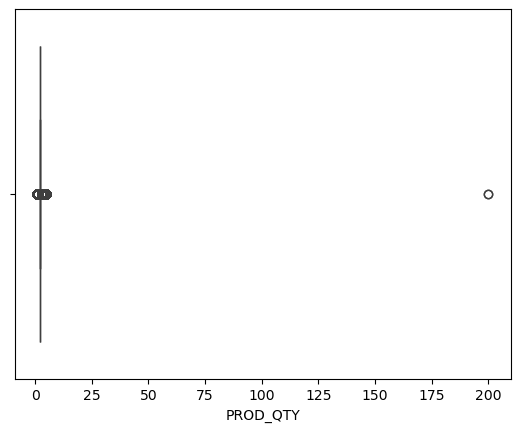

In [15]:
sns.boxplot(x=data['PROD_QTY'])
plt.show()

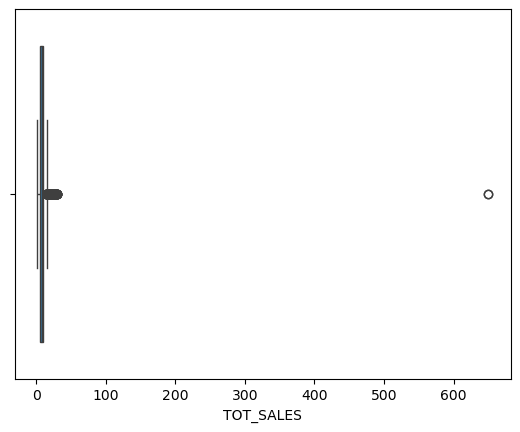

In [16]:
sns.boxplot(x=data['TOT_SALES'])
plt.show()

In [17]:
data = data[data['PROD_QTY'] < 50]

In [18]:
data['PACK_SIZE'] = data['PROD_NAME'].str.extract('(\d+)').astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\USER\AppData\Local\Temp\ipykernel_13368\1481988395.py:1: SyntaxWarning: invalid escape sequence '\d'
  data['PACK_SIZE'] = data['PROD_NAME'].str.extract('(\d+)').astype(float)


In [33]:
data['PROD_NAME']

0           Natural Chip        Compny SeaSalt175g
1                         CCs Nacho Cheese    175g
2           Smiths Crinkle Cut  Chips Chicken 170g
3           Smiths Chip Thinly  S/Cream&Onion 175g
4         Kettle Tortilla ChpsHny&Jlpno Chili 150g
                            ...                   
264831     Kettle Sweet Chilli And Sour Cream 175g
264832               Tostitos Splash Of  Lime 175g
264833                    Doritos Mexicana    170g
264834     Doritos Corn Chip Mexican Jalapeno 150g
264835               Tostitos Splash Of  Lime 175g
Name: PROD_NAME, Length: 264834, dtype: object

In [34]:
data['PACK_SIZE']

0         175.0
1         175.0
2         170.0
3         175.0
4         150.0
          ...  
264831    175.0
264832    175.0
264833    170.0
264834    150.0
264835    175.0
Name: PACK_SIZE, Length: 264834, dtype: float64

In [19]:
data['BRAND'] = data['PROD_NAME'].str.split().str[0]

In [36]:
data['PROD_NAME']

0           Natural Chip        Compny SeaSalt175g
1                         CCs Nacho Cheese    175g
2           Smiths Crinkle Cut  Chips Chicken 170g
3           Smiths Chip Thinly  S/Cream&Onion 175g
4         Kettle Tortilla ChpsHny&Jlpno Chili 150g
                            ...                   
264831     Kettle Sweet Chilli And Sour Cream 175g
264832               Tostitos Splash Of  Lime 175g
264833                    Doritos Mexicana    170g
264834     Doritos Corn Chip Mexican Jalapeno 150g
264835               Tostitos Splash Of  Lime 175g
Name: PROD_NAME, Length: 264834, dtype: object

In [35]:
data['BRAND']

0          Natural
1              CCs
2           Smiths
3           Smiths
4           Kettle
            ...   
264831      Kettle
264832    Tostitos
264833     Doritos
264834     Doritos
264835    Tostitos
Name: BRAND, Length: 264834, dtype: object

In [20]:
data['MONTH_ID'] = data['DATE'].dt.to_period('M')

In [41]:
data['MONTH_ID']

0         2018-10
1         2019-05
2         2019-05
3         2018-08
4         2018-08
           ...   
264831    2019-03
264832    2018-08
264833    2018-11
264834    2018-12
264835    2018-09
Name: MONTH_ID, Length: 264834, dtype: period[M]

In [21]:
monthly = data.groupby(['STORE_NBR', 'MONTH_ID']).agg({
    'TOT_SALES': 'sum',
    'LYLTY_CARD_NBR': pd.Series.nunique,
    'TXN_ID': 'count'
}).reset_index()

In [37]:
monthly

,STORE_NBR,MONTH_ID,TOTAL_SALES,NUM_CUSTOMERS,NUM_TRANSACTIONS,AVG_TXN_PER_CUSTOMER
0,1,2018-07,206.9,49,52,1.061224
1,1,2018-08,176.1,42,43,1.023810
2,1,2018-09,278.8,59,62,1.050847
3,1,2018-10,188.1,44,45,1.022727
4,1,2018-11,192.6,46,47,1.021739
...,...,...,...,...,...,...
3164,272,2019-02,395.5,45,48,1.066667
3165,272,2019-03,442.3,50,53,1.060000
3166,272,2019-04,445.1,54,56,1.037037
3167,272,2019-05,314.6,34,40,1.176471


In [22]:
monthly.rename(columns={
    'TOT_SALES': 'TOTAL_SALES',
    'LYLTY_CARD_NBR': 'NUM_CUSTOMERS',
    'TXN_ID': 'NUM_TRANSACTIONS'
}, inplace=True)

In [23]:
monthly['AVG_TXN_PER_CUSTOMER'] = monthly['NUM_TRANSACTIONS'] / monthly['NUM_CUSTOMERS']

In [38]:
monthly['AVG_TXN_PER_CUSTOMER'] 

0       1.061224
1       1.023810
2       1.050847
3       1.022727
4       1.021739
          ...   
3164    1.066667
3165    1.060000
3166    1.037037
3167    1.176471
3168    1.088235
Name: AVG_TXN_PER_CUSTOMER, Length: 3169, dtype: float64

In [40]:
monthly

,STORE_NBR,MONTH_ID,TOTAL_SALES,NUM_CUSTOMERS,NUM_TRANSACTIONS,AVG_TXN_PER_CUSTOMER
0,1,2018-07,206.9,49,52,1.061224
1,1,2018-08,176.1,42,43,1.023810
2,1,2018-09,278.8,59,62,1.050847
3,1,2018-10,188.1,44,45,1.022727
4,1,2018-11,192.6,46,47,1.021739
...,...,...,...,...,...,...
3164,272,2019-02,395.5,45,48,1.066667
3165,272,2019-03,442.3,50,53,1.060000
3166,272,2019-04,445.1,54,56,1.037037
3167,272,2019-05,314.6,34,40,1.176471


In [39]:
pre_trial = monthly[monthly['MONTH_ID'] < '2019-02']
trial_period = monthly[(monthly['MONTH_ID'] >= '2019-02') & (monthly['MONTH_ID'] <= '2019-04')]

In [25]:
trial_store = 77

trial_data = pre_trial[pre_trial['STORE_NBR'] == trial_store]

correlations = []

for store in pre_trial['STORE_NBR'].unique():
    if store == trial_store:
        continue
        
    control_data = pre_trial[pre_trial['STORE_NBR'] == store]
    
    merged = pd.merge(trial_data, control_data, on='MONTH_ID', suffixes=('_trial', '_control'))
    
    if len(merged) > 1:
        corr = merged['TOTAL_SALES_trial'].corr(merged['TOTAL_SALES_control'])
        correlations.append((store, corr))

corr_df = pd.DataFrame(correlations, columns=['STORE_NBR', 'CORRELATION'])
corr_df.sort_values(by='CORRELATION', ascending=False).head()

,STORE_NBR,CORRELATION
30,31,1.000000
10,11,1.000000
70,71,0.914106
225,233,0.903774
114,119,0.867664


In [26]:
merged['DIFF'] = abs(merged['TOTAL_SALES_trial'] - merged['TOTAL_SALES_control'])
score = 1 - (merged['DIFF'].mean() - merged['DIFF'].min()) / (merged['DIFF'].max() - merged['DIFF'].min())

In [27]:
def find_control_store(trial_store, pre_trial):
    trial_data = pre_trial[pre_trial['STORE_NBR'] == trial_store]
    scores = []

    for store in pre_trial['STORE_NBR'].unique():
        if store == trial_store:
            continue
            
        control_data = pre_trial[pre_trial['STORE_NBR'] == store]
        merged = pd.merge(trial_data, control_data, on='MONTH_ID', suffixes=('_trial', '_control'))
        
        if len(merged) > 1:
            corr = merged['TOTAL_SALES_trial'].corr(merged['TOTAL_SALES_control'])
            scores.append((store, corr))

    result = pd.DataFrame(scores, columns=['STORE_NBR', 'SCORE'])
    return result.sort_values(by='SCORE', ascending=False).head(1)

In [28]:
find_control_store(86, pre_trial)

,STORE_NBR,SCORE
30,31,1.0


In [29]:
find_control_store(77, pre_trial)

,STORE_NBR,SCORE
30,31,1.0


In [30]:
find_control_store(88, pre_trial)

,STORE_NBR,SCORE
154,159,0.903186


In [31]:
comparison = trial_period[trial_period['STORE_NBR'].isin([trial_store,find_control_store])]